# Seasonality 
* Salinity
* Currents
* Temperature
* Winds (?)

In [1]:
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Salinity and Currents 0-7m

In [3]:
sal = xr.open_dataset('Sal_m_0_7m.zarr').compute()
sal

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 499, lon: 1260, time: 264)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
Data variables:
    sal      (time, lat, lon) float64 1GB 35.74 35.74 35.74 ... nan nan nan

In [4]:
mesh = xr.open_dataset("/work/bk1450/b383184/Amazon/Mercator/data/Hgr_cmesh.nc").isel(t=0).compute()
mesh

<xarray.Dataset> Size: 70MB
Dimensions:       (y: 499, x: 1260, z: 50)
Dimensions without coordinates: y, x, z
Data variables: (12/21)
    nav_lon       (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
    nav_lev       (z) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    time_counter  float64 8B 0.0
    glamt         (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    glamu         (y, x) float32 3MB -94.96 -94.88 -94.79 ... 9.805 9.889 9.972
    ...            ...
    e1f           (y, x) float64 5MB 9.128e+03 9.128e+03 ... 8.028e+03 8.028e+03
    e2t           (y, x) float64 5MB 9.127e+03 9.127e+03 ... 7.847e+03 7.845e+03
    e2u           (y, x) float64 5MB 9.127e+03 9.127e+03 ... 7.846e+03 7.845e+03
    e2v           (y, x) float64 5MB 9.128e+03 9.128e+03 ... 7.843e+03 7.841e+03
    e2f           (y, x) float64 5MB 9.128e+03 9.128e+03 ... 7.842e+03 7.841e+03
    ff            (y, x) float64 5MB -2.51e-05 -2.51e-05 ... 7.288e-05 7.288e-05
Attributes:
    file_name:            mesh_hgr.nc
    TimeStamp:            03/02/2016 10:24:55 -0000
    Unlimited_Dimension:  t

In [5]:
u =  xr.open_zarr('U_m_0_7m.zarr').compute()
u = u.rename({'time_counter':'time'})
print(u)

v =  xr.open_zarr('V_m_0_7m.zarr').compute()
v = v.rename({'time_counter':'time'})
print(v)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 264, y: 499, x: 1260)
Coordinates:
    nav_lat  (y, x) float32 3MB -9.95 -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
    nav_lon  (y, x) float32 3MB -94.96 -94.88 -94.79 ... 9.805 9.889 9.972
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * x        (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y        (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
Data variables:
    U        (time, y, x) float64 1GB -0.1345 -0.1377 -0.1375 ... nan nan nan
<xarray.Dataset> Size: 1GB
Dimensions:  (time: 264, y: 499, x: 1260)
Coordinates:
    nav_lat  (y, x) float32 3MB -9.909 -9.909 -9.909 ... 29.98 29.98 29.98
    nav_lon  (y, x) float32 3MB -95.0 -94.92 -94.83 -94.75 ... 9.764 9.847 9.93
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * x        (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y        (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+0

In [6]:
U_ = seasonality((u.U.shift(x=1) + u.U)*0.5)
V_ = seasonality((v.V.shift(y=1) + v.V)*0.5)

In [7]:
# ── Precompute everything that doesn't change ───────────
lon_T = mesh["glamt"].values
lat_T = mesh["gphit"].values

s = 10
lon_s = lon_T[::s, ::s]
lat_s = lat_T[::s, ::s]

# Precompute land feature once (expensive to rebuild 12×)
land = cfeature.LAND
coast = cfeature.COASTLINE

extent = [-80, -10, -5, 20]
proj = ccrs.PlateCarree()

# Pre-stack all months into a single array for vectorized access
# Assumes U_, V_ have a 'month' dim 1..12
U_all = U_.values   # shape (12, y, x) — one load, no .sel() overhead per iter
V_all = V_.values

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

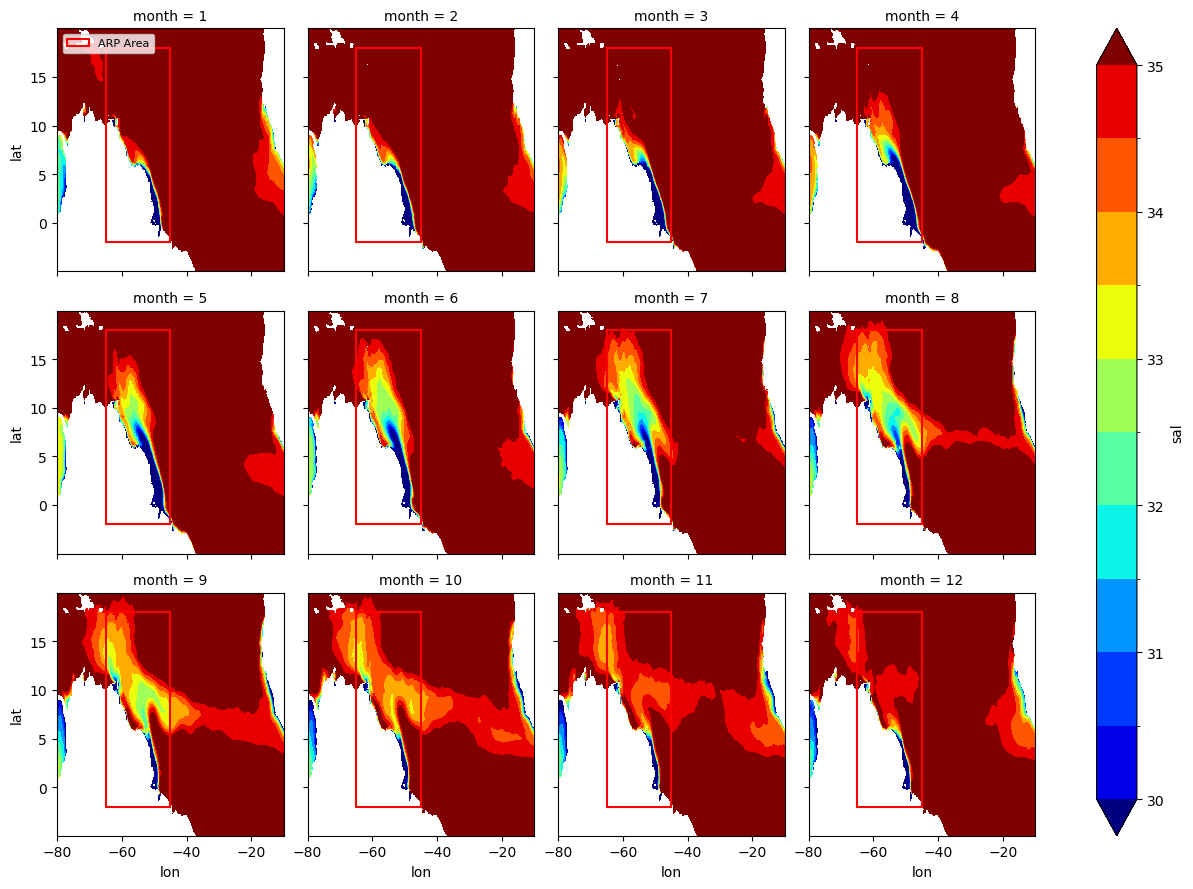

In [8]:
# Create the facet plot
g = seasonality(sal.sel(lat=slice(-5,20), lon=slice(-80,-10)).sal).plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4, cmap='jet',levels=11,vmax=35,vmin=30
)

# Loop over all axes and add the rectangle
for ax in g.axs.flat:
    rect = mpatches.Rectangle(
        xy=(-65, -2),
        width=20,
        height=20,
        linewidth=1.5,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

# Add legend to the first subplot (optional)
g.axs.flat[0].legend(['ARP Area'], loc='upper left', fontsize=8)

# plt.tight_layout()
plt.show()

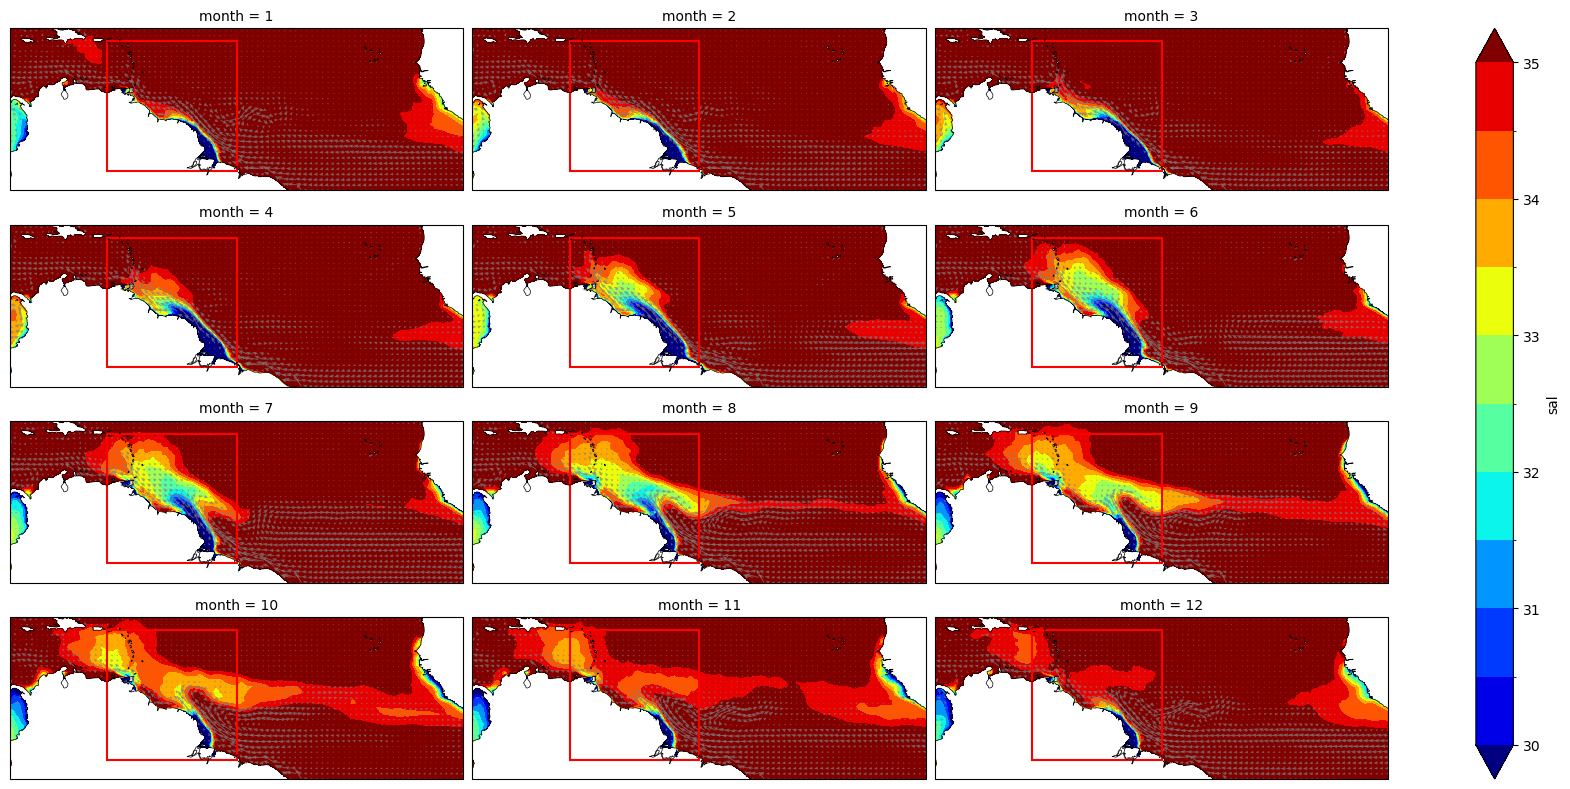

In [9]:
g = seasonality(sal.sel(lat=slice(-5,20), lon=slice(-80,-10)).sal).plot.contourf(
    x="lon", y="lat", col="month", col_wrap=3, cmap='jet', levels=11, vmax=35, vmin=30,
    subplot_kws={"projection": ccrs.PlateCarree()},   # ← forces GeoAxes
    transform=ccrs.PlateCarree(),   
    size=2,            # ← height of each panel in inches
    aspect=2.8# ← tells xarray the data CRS
)

s = 10

for ii, ax in enumerate(g.axs.flat):
    if ii >= 12:
        break

    ax.set_extent(extent, crs=ccrs.PlateCarree())      # ← set_extent, not extent
    ax.coastlines(linewidth=0.5)

    ax.quiver(
        lon_s, lat_s,
        U_all[ii, ::s, ::s], V_all[ii, ::s, ::s],
        scale=30, width=0.002, headwidth=4,
        transform=ccrs.PlateCarree(),
        color="gray", alpha=0.7,
    )

    rect = mpatches.Rectangle(
        xy=(-65, -2), width=20, height=20,
        linewidth=1.5, edgecolor='red', facecolor='none',
        transform=ccrs.PlateCarree(),                   # ← also needs transform
    )
    ax.add_patch(rect)

# g.axs.flat[0].legend(['ARP Area'], loc='upper left', fontsize=8)
# plt.savefig("figures/sal_currents_monthly.png", dpi=300, bbox_inches="tight")
plt.show()